# Развертывание ML-моделей: диф. зачет

### Шаг 1. Постановка цели. Выберите самую простую и понимаемую бизнес-задачу (например, для расчета складских запасов магазина достаточно трех таблиц — товар, склад, заказ). Выберите одну бизнес-метрику. Перепишите бизнес-требования на язык ML-проектирования.

Для визуализации цели я взял своб работу по хакатону и решил её правильно упаковать.

- Бизнес-задача: Удержание студентов на онлайн-платформе (EdTech). Платформа теряет деньги, когда студенты бросают курсы на середине. Нужно находить тех, кто собирается отвалиться, до того, как они это сделают, чтобы кураторы успели вмешаться.

- Бизнес-метрика: Повышение Retention Rate (процента удержания) и ROI (возврат инвестиций) от работы отдела кураторов.

- Язык ML-проектирования: Задача Survival Analysis (Анализ выживаемости). Необходимо спрогнозировать риск (Hazard Score) оттока студента в зависимости от времени, проведенного на платформе,

### Шаг 2. Выбор уровня сложности реализуемой системы. 

1. Предыстория    
Школа онлайн обучения несет убытки из-за оттока студентов, который сложно предсказать. Текущий подход работы (когда студент уже перестал заходить) неэффективен. Кураторам нужен инструмент, который подсвечивает студентов из зоны риска заранее, чтобы с ними можно проводить корректирующие мероприятия.

2. Ценностное предложение   
Продукт автоматически рассчитывает hazard_score для каждого студента на основе его данных в процессе обучения. Это позволяет кураторам тратить время только на тех, кому нужна помощь прямо сейчас, экономя ресурсы бизнеса.

3. Цели
- Разработать пайплайн валидации и обработки исторических данных студентов.
- Обучить модель выживаемости (Survival Model).
- Настроить автоматическое версионирование моделей и метрик.
- Развернуть API для инференса в реальном времени.

4. Решение
Разрабатывается MLOps-платформа Уровня 2.
Фичи: Пайплайн на Dagster, трекинг экспериментов в MLflow, API на FastAPI, мониторинг через Prometheus/Grafana. Модель прогнозирования — Cox Proportional Hazards (CoxPH).    
Интеграции: Чтение фичей из PostgreSQL, отдача прогнозов через REST API.     
Ограничения/Что не входит: Система только выдает скоринг риска. Автоматическая рассылка писем студентам в скоуп не входит (остается на стороне CRM заказчика).     
Заявленный уровень зрелости: Уровень 2 (Полная автоматизация, оркестрация, CI/CD, трекинг и мониторинг).    

5. Осуществимость
Решение полностью осуществимо. В наличии имеются вычислительные ресурсы (выделенный сервер, хоть и в минимальном виде, так как оперативной памяти ровно впритык, работает пока данное решение тяжело) и необходимые компетенции для развертывания микросервисной архитектуры (Docker Compose).

6. Данные
Обучающий набор: Исторические данные выгрузок из LMS (активность, сдача ДЗ, коммуникация в чатах).
Прод набор: Потоковые логи действий студентов, поступающие через Data Gateway.
Разметка: Не требует ручной разметки. Класс события (отток/не отток) и длительность (дни) формируются автоматически из логов базы данных LMS, так как эти данные легко логгируются.

7. Метрики
Бизнес: Увеличение LTV (Lifetime Value) студента, конверсия "спасенных" студентов.    
ML: Concordance Index (C-index) для оценки качества ранжирования рисков моделью CoxPH.

8. Оценка качества модели
Офлайн-метрика: C-index на тестовой отложенной выборке (в процессе работы пайплайна).    
Онлайн-метрика: A/B тестирование в продакшене (Сравниваем процент отвала в группе, где кураторы действуют по ML-подсказкам, с контрольной группой без ML).

9. Подбор модели
Итеративный подход: старт с базовой интерпретируемой модели (CoxPH) для обеспечения прозрачности предсказаний (какая фича сильнее всего влияет на риск). В последующих итерациях — переход на ансамбли (Random Survival Forests/CatBoost) при необходимости повышения точности.

10. Инференс
Обработка сырых данных: батчами (раз в сутки через Dagster).    
Отдача прогноза hazard_score: в реальном времени по запросу к FastAPI.

11. Обратная связь
Источники: Факт ухода студента (True Label) собирается в БД с задержкой, сопоставляется с выданным ранее прогнозом.    
Использование MDD: Да. Мониторинг Data Quality, Latency и бизнес-метрики будут использоваться для запуска переобучения.

12. Управление проектом
Разработчики: 1 (больше всё равно нет).
Результаты: Развернутая система в облаке, код в репозитории с CI/CD.
Сроки: Дедлайн - 31 мая 2026.

### Шаг 3. Создание ML-системы
В файле docker-compose.yml описан полный контур Уровня 2, состоящий из 5 изолированных микросервисов, объединенных внутренней сетью backend_net.
При этом реализация не совсем полная, на текущий момент Prometheus и Dagster не связаны между собой, так как в случае падения метрик не реализовано переобучение в Dagster. Но это можно реализовать отдельно, вся инфраструктура для этого есть. 

- Feature Store (PostgreSQL): Хранилище сырых данных и признаков.

- Orchestrator (Dagster): Управляет оркестрацией, запускает проверки Data Quality (EvidentlyAI) и инициирует обучение.

- Model Registry & Tracking (MLflow): Версионирует гиперпараметры модели CoxPH, сохраняет артефакты (.pkl) и метрики (c_index).

- Serving API (FastAPI): Загружает обученную модель из общего volume и отдает инференс (hazard score) по HTTP.

- Monitoring (Prometheus + Grafana): Собирает системные и бизнес-метрики в реальном времени.

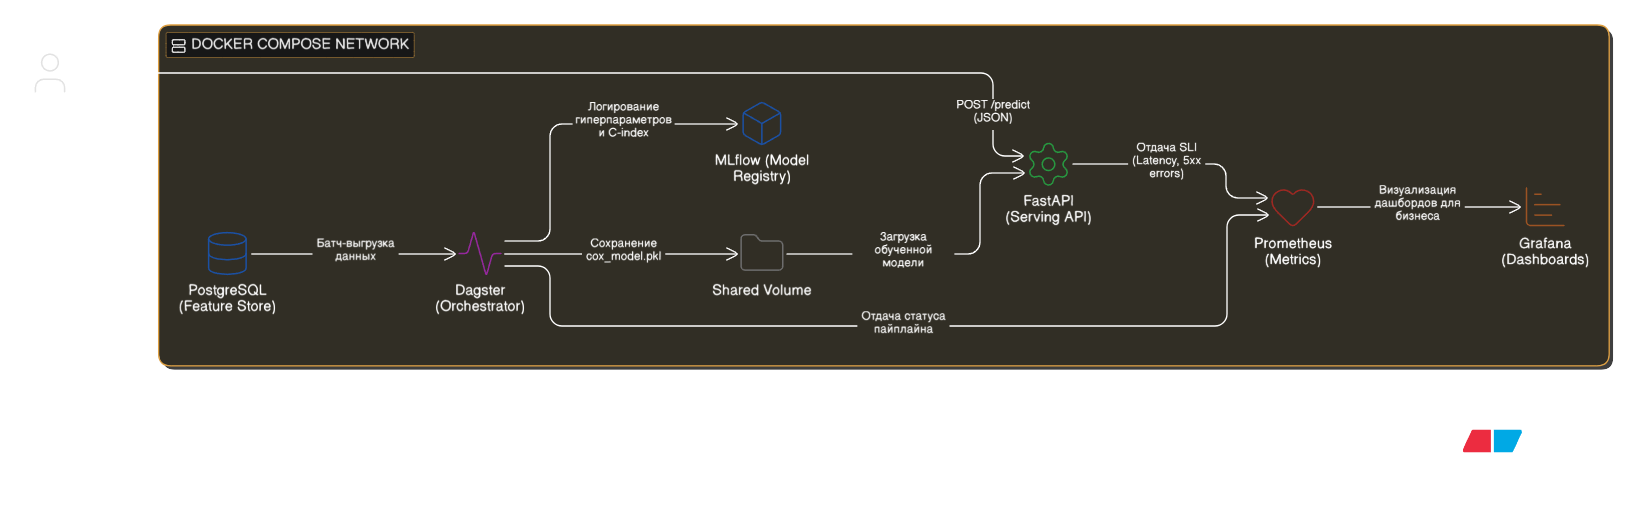